In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('dataset/california_housing_dataset.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [15]:
# Remove data points which have ['median_house_value'] > 500000
df_loc = df[df['median_house_value'].astype(int) < 500000].copy()
df_loc.shape

df_loc.isnull().sum()

#Fill NA value into ['total_bedrooms']
df_loc['total_bedrooms'] = df_loc['total_bedrooms'].fillna(df_loc['total_bedrooms'].median())
df_loc.isnull().sum()

df_loc['total_rooms_per_household'] = df_loc['total_rooms'] / df_loc['households']
df_loc['total_bedrooms_per_household'] = df_loc['total_bedrooms'] / df_loc['households']
df_loc['population_per_household'] = df_loc['total_bedrooms'] / df_loc['households']
df_loc['total_bedrooms_per_total_rooms'] = df_loc['total_bedrooms'] / df_loc['total_rooms']

df_loc["log_median_income"] = np.log1p(df_loc["median_income"])
df_loc["log_households"] = np.log1p(df_loc["households"])
df_loc["log_rooms_per_household"] = np.log1p(df_loc["total_rooms_per_household"])
df_loc["log_population_per_household"] = np.log1p(df_loc["population_per_household"])
df_loc["log_median_house_value"] = np.log1p(df_loc["median_house_value"])
df_loc["log_total_bedrooms_per_total_rooms"] = np.log1p(df_loc["total_bedrooms_per_total_rooms"])

df_loc = df_loc.drop(['total_rooms', 'total_bedrooms', 'population', 'total_bedrooms_per_household'], axis=1)

df_loc.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,ocean_proximity,total_rooms_per_household,population_per_household,total_bedrooms_per_total_rooms,log_median_income,log_households,log_rooms_per_household,log_population_per_household,log_median_house_value,log_total_bedrooms_per_total_rooms
0,-122.23,37.88,41.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810,0.146591,2.232720,4.844187,2.077455,0.704982,13.022766,0.136793
1,-122.22,37.86,21.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880,0.155797,2.230165,7.037906,1.979364,0.678988,12.789687,0.144790
2,-122.24,37.85,52.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446,0.129516,2.111110,5.181784,2.228738,0.729212,12.771673,0.121789
3,-122.25,37.85,52.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059,0.184458,1.893579,5.393628,1.919471,0.729025,12.740520,0.169286
4,-122.25,37.85,52.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081,0.172096,1.578195,5.560682,1.985385,0.732888,12.743154,0.158793


### Visualize Data

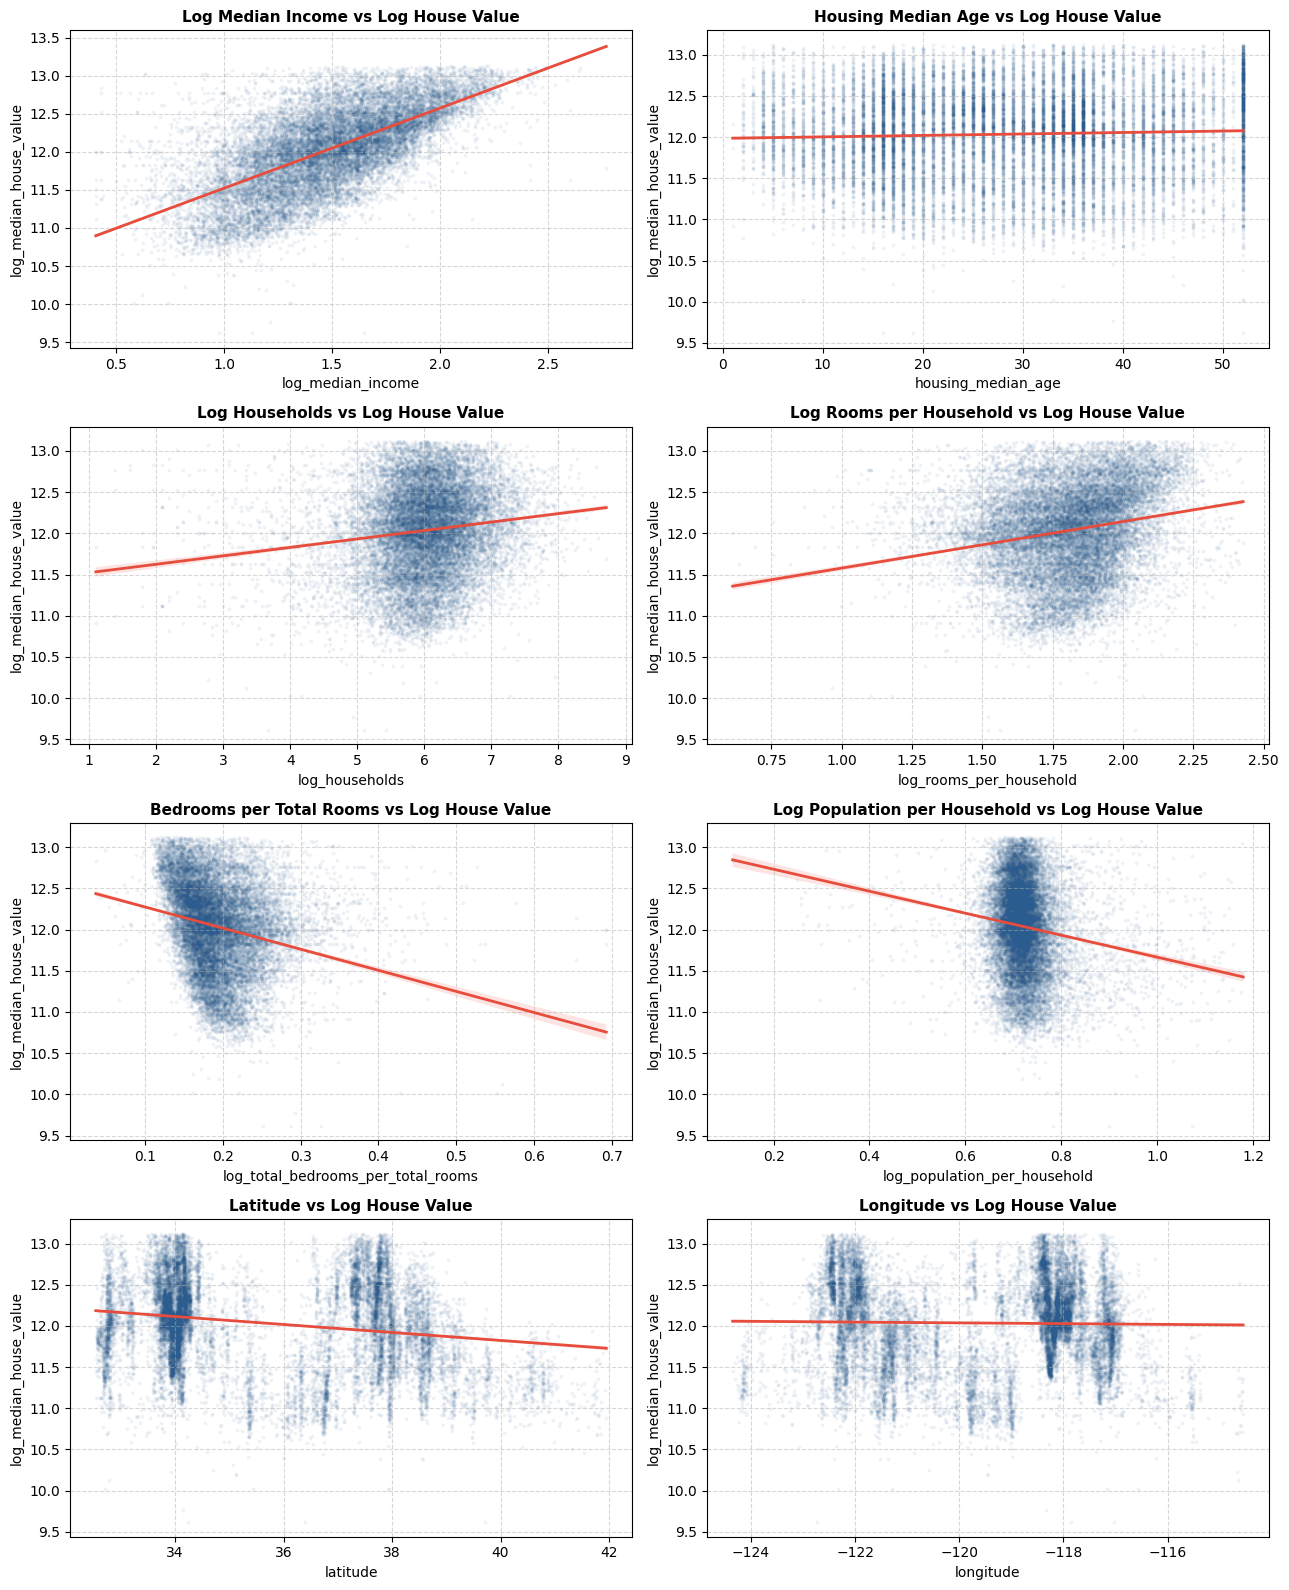

In [16]:
df_viz = df_loc[
    (df_loc['total_rooms_per_household'] < df_loc['total_rooms_per_household'].quantile(0.99)) &
    (df_loc['population_per_household'] < df_loc['population_per_household'].quantile(0.99))
].copy()

features_to_plot = [
    ('log_median_income', 'Log Median Income'),
    ('housing_median_age', 'Housing Median Age'),
    ('log_households', 'Log Households'),
    ('log_rooms_per_household', 'Log Rooms per Household'),
    ('log_total_bedrooms_per_total_rooms', 'Bedrooms per Total Rooms'),
    ('log_population_per_household', 'Log Population per Household'),
    ('latitude', 'Latitude'),
    ('longitude', 'Longitude')
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for idx, (col, title) in enumerate(features_to_plot):
    sns.regplot(
        data=df_viz, x=col, y='log_median_house_value', ax=axes[idx],
        scatter_kws={'alpha': 0.05, 's': 3, 'color': '#2b5c8f'},
        line_kws={'color': '#e74c3c', 'linewidth': 2}
    )
    axes[idx].set_title(f'{title} vs Log House Value', fontsize=11, fontweight='bold')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Scale Data and Divide Data

In [17]:
feature_cols = [
    'log_median_income',
    'housing_median_age',
    'log_households',
    'log_rooms_per_household',
    'log_total_bedrooms_per_total_rooms',
    'log_population_per_household',
    'latitude',
    'longitude'
]

y = df_loc["log_median_house_value"].values.reshape(-1, 1)
X = df_loc[feature_cols].values

np.random.seed(42)
n_samples = X.shape[0]
indices = np.random.permutation(n_samples)

train_size = int(n_samples * 0.8)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train_raw, y_test_raw = y[train_idx], y[test_idx]

X_train_mean = np.mean(X_train_raw, axis=0)
X_train_std = np.std(X_train_raw, axis=0)

X_train_scaled = (X_train_raw - X_train_mean) / X_train_std
X_test_scaled = (X_test_raw - X_train_mean) / X_train_std

X_train = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

### Training Data

In [33]:
n_samples_train, n_features = X_train.shape
theta = np.zeros((n_features, 1))

In [47]:
learning_rate = 0.05
epochs = 50000

In [48]:
for epoch in range(epochs):

    y_pred_train = X_train @ theta

    error = y_train_raw - y_pred_train
    grad = -(1 / n_sample_trains) * (X_train.T @ error)
    theta = theta - learning_rate * grad
    
    if epoch % 500 == 0:
        current_loss = (1 / (2 * n_samples_train)) * np.sum(
            (error) ** 2
        )
        print(f"Epoch {epoch:4d}/{epochs} | Training MSE Loss: {current_loss:.6f}")


Epoch    0/50000 | Training MSE Loss: 426888263853485107028813562023944632315957128953008508312644368801876481072282715094569501511715673128354770387333512288307279211458449935996595528948560470167338537485909091703085660069203991628306885382077148999188734156783458582717434726644359594398724878369313259520.000000
Epoch  500/50000 | Training MSE Loss: 196446984166908478190324763085850404900801984388693656498333950351349449297404748223463602860748044970341071127590710671708563690454454617332725115575049849859340293460010267227437203056352633534255892462357019045786618704570663213667587027048200426313810176447933841408.000000
Epoch 1000/50000 | Training MSE Loss: 90401683194361083214345389239804004287148812671229903858360012187304017945255790694086199992781042055951169258372092677476619655560525019041328312382819535326869436247591138568262799133521186898371972173152478500483922029936594716715642262964379198882897294219271995392.000000
Epoch 1500/50000 | Training MSE Loss: 416013733121502

In [51]:
y_pred_log = X_test @ theta
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_raw)

test_rmse = np.sqrt(np.mean((y_pred_real - y_test_real) ** 2))

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_29045/696449398.py:2: RuntimeWarning: overflow encountered in expm1
  y_pred_real = np.expm1(y_pred_log)


In [52]:
print(f"{'Feature Name':30s} | {'Coefficient (Theta)':>20s}")
print("-" * 55)

feature_names = ["Intercept (b)"] + feature_cols
for name, coef in zip(feature_names, theta.flatten()):
    print(f"{name:30s} | {coef:+20.6f}")

Feature Name                   |  Coefficient (Theta)
-------------------------------------------------------
Intercept (b)                  | +2857241423811429888822898437150329308396358941382089067151201192198073669465296675520478278470514937692160.000000
log_median_income              | +9459883064777066325595766466909738560017560150359897497597315666801457917045209682757238831213056935493130593035616256.000000
housing_median_age             | -944992145799120927354567821539471071119388132900896452318849861840333007320596378147058618954674956893164237181943808.000000
log_households                 | -1015425941786529559660524818461770321008087614988652795936169623655858786042038100230886893645231027773054943330566144.000000
log_rooms_per_household        | -71156450030615190306215553374349163815600848941757382229228615763325695662683020491953904801272671228062740553385639936.000000
log_total_bedrooms_per_total_rooms | -5529608366279620672340533416902349712052577706812769612683603789